## Step 12 — Imports and settings

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

## Step 12.1 — Load the processed datasets

In [2]:
DATA_DIR = Path(".")

daily_path   = DATA_DIR / "weather_daily_clean_processed.csv"
monthly_path = DATA_DIR / "weather_monthly_station.csv"
annual_path  = DATA_DIR / "weather_annual_station.csv"
model_path   = DATA_DIR / "weather_model_t1.csv"

for p in [daily_path, monthly_path, annual_path, model_path]:
    if not p.exists():
        raise FileNotFoundError(f"Missing file: {p}")

df_daily   = pd.read_csv(daily_path, parse_dates=["date"])
df_monthly = pd.read_csv(monthly_path)
df_annual  = pd.read_csv(annual_path)
df_model   = pd.read_csv(model_path, parse_dates=["date"])

print("Daily:", df_daily.shape)
print("Monthly:", df_monthly.shape)
print("Annual:", df_annual.shape)
print("Model:", df_model.shape)

Daily: (543839, 108)
Monthly: (17868, 8)
Annual: (1489, 6)
Model: (542754, 73)


## Step 12.2 — Create output folders for forecasting and ML

In [3]:
os.makedirs("results_ml", exist_ok=True)
os.makedirs("results_ml/figures", exist_ok=True)
os.makedirs("results_ml/tables", exist_ok=True)
os.makedirs("results_ml/models", exist_ok=True)

## Step 12.3 — Check columns

In [4]:
print("Daily columns:")
print(df_daily.columns.tolist())

print("\nModel columns:")
print(df_model.columns.tolist())

Daily columns:
['date', 'station', 'rainfall', 'sunshine', 'humidity', 'temperature', 'was_missing_row', 'year', 'month', 'day', 'dayofyear', 'weekofyear', 'quarter', 'season', 'is_monsoon', 'rainfall_flag_invalid', 'humidity_flag_invalid', 'sunshine_flag_invalid', 'temperature_flag_invalid', 'temperature_imputed_flag', 'humidity_imputed_flag', 'sunshine_imputed_flag', 'rainfall_imputed_flag', 'month_sin', 'month_cos', 'doy_sin', 'doy_cos', 'station_mean_rainfall', 'station_mean_temperature', 'station_mean_humidity', 'station_mean_sunshine', 'rainfall_month_clim', 'temperature_month_clim', 'humidity_month_clim', 'sunshine_month_clim', 'rainfall_anomaly', 'temperature_anomaly', 'humidity_anomaly', 'sunshine_anomaly', 'rainfall_lag1', 'rainfall_lag3', 'rainfall_lag7', 'rainfall_lag14', 'rainfall_lag30', 'temperature_lag1', 'temperature_lag3', 'temperature_lag7', 'temperature_lag14', 'temperature_lag30', 'humidity_lag1', 'humidity_lag3', 'humidity_lag7', 'humidity_lag14', 'humidity_lag30'

## Step 12.4 — Forecasting targets and train/validation/test split

In [5]:
target_cols = [
    "target_rainfall_t1",
    "target_temperature_t1",
    "target_humidity_t1",
    "target_sunshine_t1"
]

train_df = df_model[df_model["date"] < "2018-01-01"].copy()
valid_df = df_model[(df_model["date"] >= "2018-01-01") & (df_model["date"] < "2021-01-01")].copy()
test_df  = df_model[df_model["date"] >= "2021-01-01"].copy()

print("Train:", train_df.shape)
print("Validation:", valid_df.shape)
print("Test:", test_df.shape)

print(train_df["date"].min(), train_df["date"].max())
print(valid_df["date"].min(), valid_df["date"].max())
print(test_df["date"].min(), test_df["date"].max())

Train: (466104, 73)
Validation: (38360, 73)
Test: (38290, 73)
1961-01-31 00:00:00 2017-12-31 00:00:00
2018-01-01 00:00:00 2020-12-31 00:00:00
2021-01-01 00:00:00 2023-12-30 00:00:00


## Step 12.5 — Keep stations with enough data in all three splits

In [6]:
split_check = pd.DataFrame({
    "train_rows": train_df["station"].value_counts(),
    "valid_rows": valid_df["station"].value_counts(),
    "test_rows": test_df["station"].value_counts()
}).fillna(0).astype(int)

min_train_rows = 365
min_valid_rows = 90
min_test_rows = 90

eligible_stations = split_check[
    (split_check["train_rows"] >= min_train_rows) &
    (split_check["valid_rows"] >= min_valid_rows) &
    (split_check["test_rows"] >= min_test_rows)
].index.tolist()

train_df = train_df[train_df["station"].isin(eligible_stations)].copy()
valid_df = valid_df[valid_df["station"].isin(eligible_stations)].copy()
test_df  = test_df[test_df["station"].isin(eligible_stations)].copy()

print("Eligible stations:", len(eligible_stations))
print(eligible_stations[:10])
split_check.loc[eligible_stations].head()

Eligible stations: 35
['ambaganctg', 'barisal', 'bhola', 'bogra', 'chandpur', 'chittagong', 'chuadanga', 'comilla', 'coxsbazar', 'dhaka']


,train_rows,valid_rows,test_rows
station,,,
ambaganctg,3623,1096,1094
barisal,18598,1096,1094
bhola,13484,1096,1094
bogra,20789,1096,1094
chandpur,14945,1096,1094


## Step 12.6 — Build X and y matrices

In [7]:
drop_cols = ["date"] + target_cols

X_train_raw = train_df.drop(columns=drop_cols).copy()
X_valid_raw = valid_df.drop(columns=drop_cols).copy()
X_test_raw  = test_df.drop(columns=drop_cols).copy()

y_train = train_df[target_cols].copy()
y_valid = valid_df[target_cols].copy()
y_test  = test_df[target_cols].copy()

# one-hot encode station
X_train = pd.get_dummies(X_train_raw, columns=["station"], drop_first=False)
X_valid = pd.get_dummies(X_valid_raw, columns=["station"], drop_first=False)
X_test  = pd.get_dummies(X_test_raw, columns=["station"], drop_first=False)

X_train, X_valid = X_train.align(X_valid, join="left", axis=1, fill_value=0)
X_train, X_test  = X_train.align(X_test, join="left", axis=1, fill_value=0)

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)

X_train: (466104, 102)
X_valid: (38360, 102)
X_test : (38290, 102)
y_train: (466104, 4)


## Step 12.7 — Evaluation functions

In [9]:
def smape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2
    denom = np.where(denom == 0, 1e-8, denom)
    return np.mean(np.abs(y_true - y_pred) / denom) * 100

def evaluate_regression(y_true_df, y_pred_df, model_name):
    rows = []
    for col in y_true_df.columns:
        yt = y_true_df[col].values
        yp = y_pred_df[col].values
        rows.append({
            "model": model_name,
            "target": col,
            "MAE": mean_absolute_error(yt, yp),
            "RMSE": np.sqrt(mean_squared_error(yt, yp)),
            "R2": r2_score(yt, yp),
            "SMAPE": smape(yt, yp)
        })
    return pd.DataFrame(rows)

def plot_target_comparison(results_df, metric="RMSE", title=None, save_name=None):
    plt.figure(figsize=(12, 6))
    sns.barplot(data=results_df, x="target", y=metric, hue="model")
    plt.title(title if title else f"{metric} comparison across models")
    plt.xticks(rotation=15)
    plt.tight_layout()
    if save_name:
        plt.savefig(save_name, dpi=300)
    plt.show()

## Step 13 — Baseline 1: Persistence forecast

In [10]:
persist_map = {
    "target_rainfall_t1": "rainfall_lag1",
    "target_temperature_t1": "temperature_lag1",
    "target_humidity_t1": "humidity_lag1",
    "target_sunshine_t1": "sunshine_lag1"
}

persist_pred = pd.DataFrame(index=test_df.index)

for target, source in persist_map.items():
    persist_pred[target] = test_df[source].values

persist_results = evaluate_regression(y_test, persist_pred, "Persistence_lag1")
persist_results

,model,target,MAE,RMSE,R2,SMAPE
0,Persistence_lag1,target_rainfall_t1,8.294594,22.398801,-0.567123,67.435515
1,Persistence_lag1,target_temperature_t1,1.161611,1.533516,0.866808,4.636472
2,Persistence_lag1,target_humidity_t1,4.832881,6.451286,0.438400,6.241102
3,Persistence_lag1,target_sunshine_t1,2.641139,3.621235,-0.234784,64.864788


## Step 14 — Baseline 2: 7-day rolling mean forecast

In [11]:
roll_map = {
    "target_rainfall_t1": "rainfall_rollmean_7",
    "target_temperature_t1": "temperature_rollmean_7",
    "target_humidity_t1": "humidity_rollmean_7",
    "target_sunshine_t1": "sunshine_rollmean_7"
}

roll_pred = pd.DataFrame(index=test_df.index)

for target, source in roll_map.items():
    roll_pred[target] = test_df[source].values

roll_results = evaluate_regression(y_test, roll_pred, "RollingMean7")
roll_results

,model,target,MAE,RMSE,R2,SMAPE
0,RollingMean7,target_rainfall_t1,7.815058,18.393029,-0.056721,95.745302
1,RollingMean7,target_temperature_t1,1.277107,1.620987,0.851181,5.126766
2,RollingMean7,target_humidity_t1,4.786628,6.299424,0.464528,6.191103
3,RollingMean7,target_sunshine_t1,2.459872,3.156279,0.061945,56.760365


## Step 15 — Multi-output Random Forest regression

In [14]:
import time

start = time.time()
rf_model = RandomForestRegressor(
    n_estimators=50,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Training time:", round(time.time() - start, 2), "seconds")

rf_pred = pd.DataFrame(
    rf_model.predict(X_test),
    columns=target_cols,
    index=y_test.index
)

rf_results = evaluate_regression(y_test, rf_pred, "RandomForest_multioutput")
rf_results

Training time: 188.92 seconds


,model,target,MAE,RMSE,R2,SMAPE
0,RandomForest_multioutput,target_rainfall_t1,5.351187,13.973302,0.390110,165.285051
1,RandomForest_multioutput,target_temperature_t1,1.174368,1.473976,0.876950,4.682875
2,RandomForest_multioutput,target_humidity_t1,3.888267,5.115054,0.646951,5.029174
3,RandomForest_multioutput,target_sunshine_t1,2.191898,2.811046,0.255931,51.227323


In [15]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = pd.DataFrame(
    rf_model.predict(X_test),
    columns=target_cols,
    index=y_test.index
)

rf_results = evaluate_regression(y_test, rf_pred, "RandomForest_multioutput")
rf_results

,model,target,MAE,RMSE,R2,SMAPE
0,RandomForest_multioutput,target_rainfall_t1,5.417473,13.751254,0.409339,165.068978
1,RandomForest_multioutput,target_temperature_t1,1.014188,1.283079,0.906759,4.025165
2,RandomForest_multioutput,target_humidity_t1,3.723538,4.913694,0.674200,4.818934
3,RandomForest_multioutput,target_sunshine_t1,2.121458,2.718720,0.304004,50.915813


## Step 16 — Multi-output ElasticNet regression

In [16]:
enet_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", MultiOutputRegressor(
        ElasticNet(alpha=0.001, l1_ratio=0.5, random_state=42, max_iter=5000)
    ))
])

enet_model.fit(X_train, y_train)

enet_pred = pd.DataFrame(
    enet_model.predict(X_test),
    columns=target_cols,
    index=y_test.index
)

enet_results = evaluate_regression(y_test, enet_pred, "ElasticNet_multioutput")
enet_results

,model,target,MAE,RMSE,R2,SMAPE
0,ElasticNet_multioutput,target_rainfall_t1,7.764127,15.588046,0.241008,167.235179
1,ElasticNet_multioutput,target_temperature_t1,0.991252,1.280437,0.907143,3.976226
2,ElasticNet_multioutput,target_humidity_t1,3.769494,4.952326,0.669057,4.873024
3,ElasticNet_multioutput,target_sunshine_t1,2.072048,2.664305,0.331586,50.839428


## Step 17 — Optional XGBoost multi-output regression

In [17]:
#Uncomment this step only if xgboost is installed.
from xgboost import XGBRegressor

xgb_model = MultiOutputRegressor(
    XGBRegressor(
        n_estimators=400,
        max_depth=6,
learning_rate=0.05,
       subsample=0.8,
     colsample_bytree=0.8,
     objective="reg:squarederror",
     random_state=42,
         n_jobs=-1
 )
)

xgb_model.fit(X_train, y_train)

xgb_pred = pd.DataFrame(
    xgb_model.predict(X_test),
   columns=target_cols,
    index=y_test.index
)

xgb_results = evaluate_regression(y_test, xgb_pred, "XGBoost_multioutput")
xgb_results

,model,target,MAE,RMSE,R2,SMAPE
0,XGBoost_multioutput,target_rainfall_t1,5.245415,13.523611,0.428733,165.056629
1,XGBoost_multioutput,target_temperature_t1,0.823256,1.073537,0.934727,3.248525
2,XGBoost_multioutput,target_humidity_t1,3.591518,4.741332,0.696656,4.640903
3,XGBoost_multioutput,target_sunshine_t1,2.039090,2.620495,0.353387,50.754354


## Step 17.1 — Combine regression results

In [18]:
all_reg_results = pd.concat(
    [persist_results, roll_results, rf_results, enet_results],
    ignore_index=True
)

all_reg_results.to_csv("results_ml/tables/regression_results_baselines.csv", index=False)
all_reg_results

,model,target,MAE,RMSE,R2,SMAPE
0,Persistence_lag1,target_rainfall_t1,8.294594,22.398801,-0.567123,67.435515
1,Persistence_lag1,target_temperature_t1,1.161611,1.533516,0.866808,4.636472
2,Persistence_lag1,target_humidity_t1,4.832881,6.451286,0.438400,6.241102
3,Persistence_lag1,target_sunshine_t1,2.641139,3.621235,-0.234784,64.864788
4,RollingMean7,target_rainfall_t1,7.815058,18.393029,-0.056721,95.745302
5,RollingMean7,target_temperature_t1,1.277107,1.620987,0.851181,5.126766
6,RollingMean7,target_humidity_t1,4.786628,6.299424,0.464528,6.191103
7,RollingMean7,target_sunshine_t1,2.459872,3.156279,0.061945,56.760365
8,RandomForest_multioutput,target_rainfall_t1,5.417473,13.751254,0.409339,165.068978
9,RandomForest_multioutput,target_temperature_t1,1.014188,1.283079,0.906759,4.025165


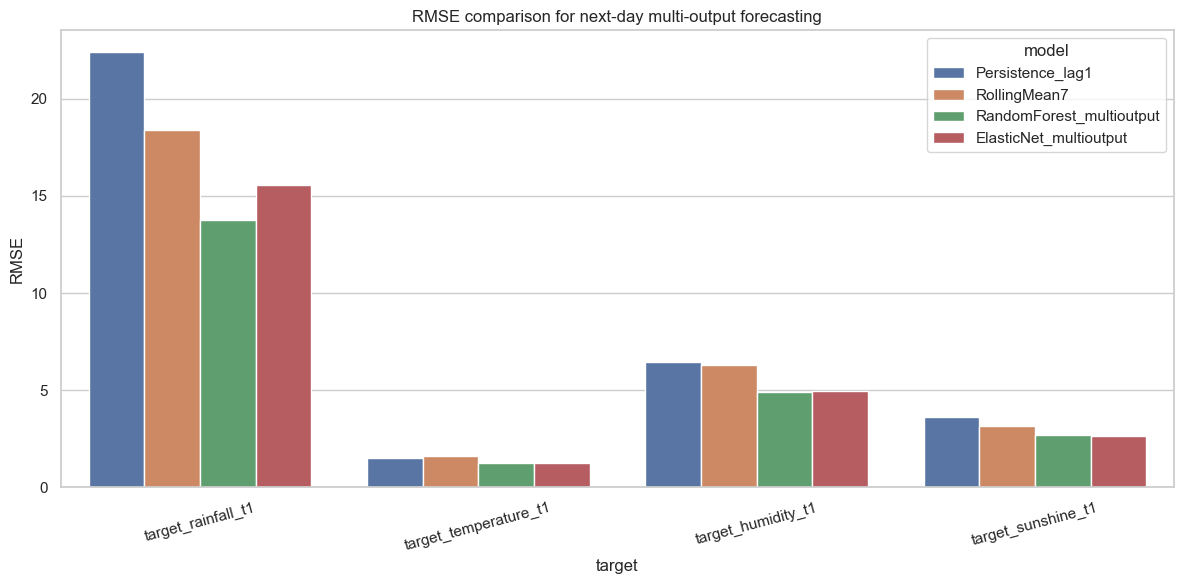

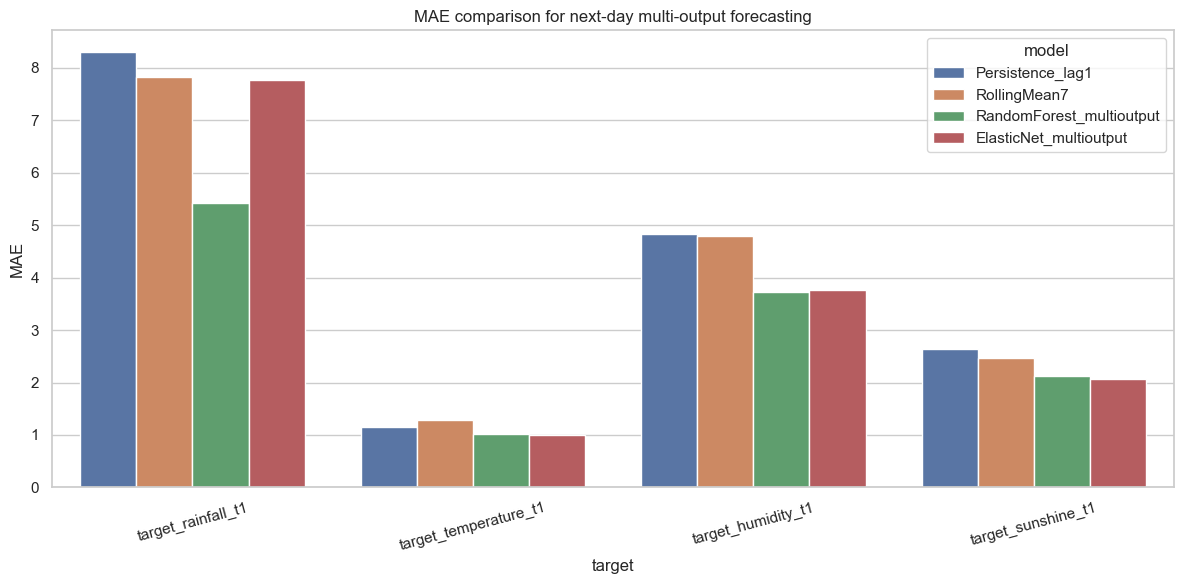

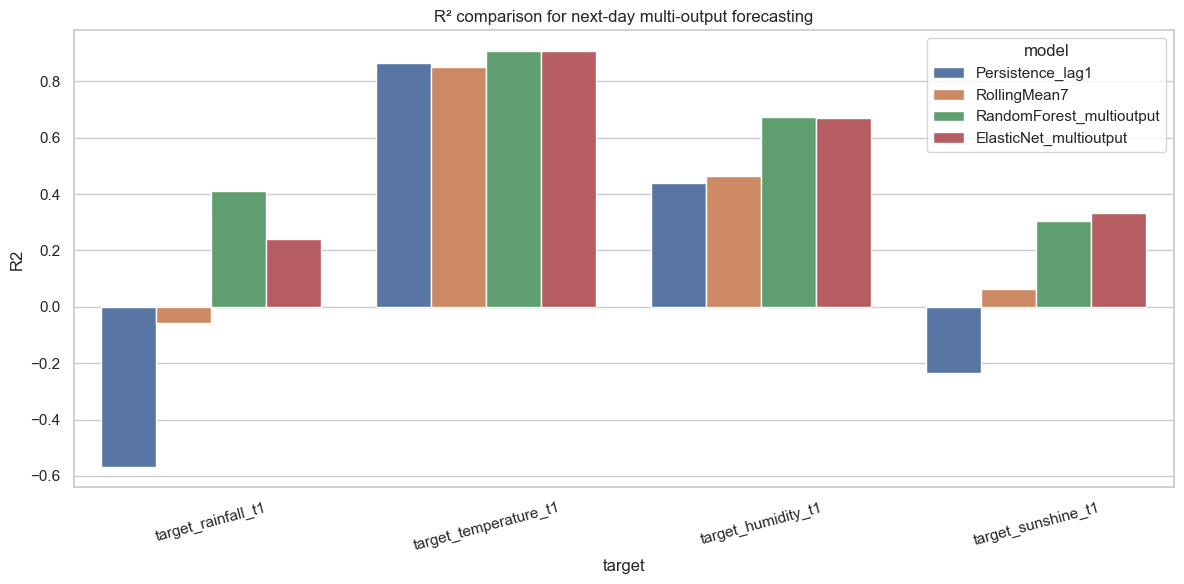

In [19]:
plot_target_comparison(
    all_reg_results,
    metric="RMSE",
    title="RMSE comparison for next-day multi-output forecasting",
    save_name="results_ml/figures/regression_rmse_comparison.png"
)

plot_target_comparison(
    all_reg_results,
    metric="MAE",
    title="MAE comparison for next-day multi-output forecasting",
    save_name="results_ml/figures/regression_mae_comparison.png"
)

plot_target_comparison(
    all_reg_results,
    metric="R2",
    title="R² comparison for next-day multi-output forecasting",
    save_name="results_ml/figures/regression_r2_comparison.png"
)



## Step 18 — Rainfall occurrence classification

In [20]:
df_cls = df_model.copy()
df_cls["target_rain_occurrence_t1"] = (df_cls["target_rainfall_t1"] > 0).astype(int)

cls_target = "target_rain_occurrence_t1"
cls_drop_cols = ["date", cls_target] + target_cols
cls_features = [c for c in df_cls.columns if c not in cls_drop_cols]

train_cls = df_cls[df_cls["date"] < "2018-01-01"].copy()
valid_cls = df_cls[(df_cls["date"] >= "2018-01-01") & (df_cls["date"] < "2021-01-01")].copy()
test_cls  = df_cls[df_cls["date"] >= "2021-01-01"].copy()

train_cls = train_cls[train_cls["station"].isin(eligible_stations)].copy()
valid_cls = valid_cls[valid_cls["station"].isin(eligible_stations)].copy()
test_cls  = test_cls[test_cls["station"].isin(eligible_stations)].copy()

X_train_cls = pd.get_dummies(train_cls[cls_features], columns=["station"], drop_first=False)
X_valid_cls = pd.get_dummies(valid_cls[cls_features], columns=["station"], drop_first=False)
X_test_cls  = pd.get_dummies(test_cls[cls_features], columns=["station"], drop_first=False)

X_train_cls, X_valid_cls = X_train_cls.align(X_valid_cls, join="left", axis=1, fill_value=0)
X_train_cls, X_test_cls  = X_train_cls.align(X_test_cls, join="left", axis=1, fill_value=0)

y_train_cls = train_cls[cls_target]
y_valid_cls = valid_cls[cls_target]
y_test_cls  = test_cls[cls_target]

print(X_train_cls.shape, y_train_cls.shape)

(466104, 102) (466104,)


In [21]:
rf_cls = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

rf_cls.fit(X_train_cls, y_train_cls)

rf_cls_pred = rf_cls.predict(X_test_cls)
rf_cls_prob = rf_cls.predict_proba(X_test_cls)[:, 1]

cls_results = pd.DataFrame([{
    "model": "RandomForestClassifier",
    "accuracy": accuracy_score(y_test_cls, rf_cls_pred),
    "precision": precision_score(y_test_cls, rf_cls_pred),
    "recall": recall_score(y_test_cls, rf_cls_pred),
    "f1": f1_score(y_test_cls, rf_cls_pred),
    "roc_auc": roc_auc_score(y_test_cls, rf_cls_prob)
}])

cls_results.to_csv("results_ml/tables/rain_occurrence_classification_results.csv", index=False)
cls_results

,model,accuracy,precision,recall,f1,roc_auc
0,RandomForestClassifier,0.855393,0.769033,0.73567,0.751982,0.925296


In [22]:
print(classification_report(y_test_cls, rf_cls_pred))

              precision    recall  f1-score   support

           0       0.89      0.91      0.90     26880
           1       0.77      0.74      0.75     11410

    accuracy                           0.86     38290
   macro avg       0.83      0.82      0.82     38290
weighted avg       0.85      0.86      0.85     38290



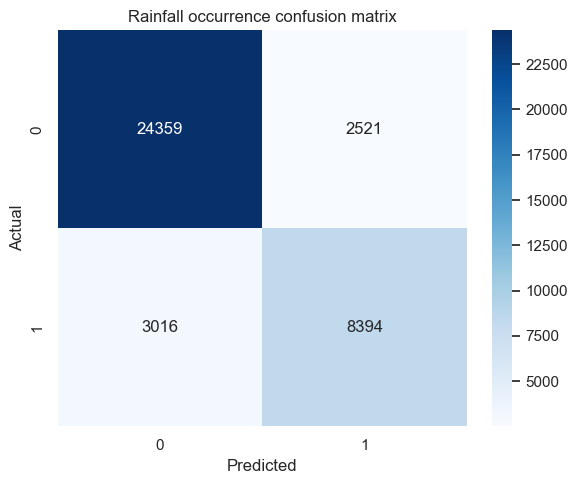

In [23]:
cm = confusion_matrix(y_test_cls, rf_cls_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Rainfall occurrence confusion matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("results_ml/figures/rain_occurrence_confusion_matrix.png", dpi=300)
plt.show()

## Step 19 — Feature importance from Random Forest regression

In [24]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance.to_csv("results_ml/tables/rf_feature_importance.csv", index=False)
feature_importance.head(20)

,feature,importance
3,humidity_anomaly,0.241606
17,is_monsoon,0.129928
4,humidity_lag1,0.045009
36,station_mean_rainfall,0.040566
53,temperature_anomaly,0.034918
39,sunshine_anomaly,0.031656
1,doy_cos,0.029405
21,rainfall_anomaly,0.020857
54,temperature_lag1,0.017685
11,humidity_rollmean_30,0.014310


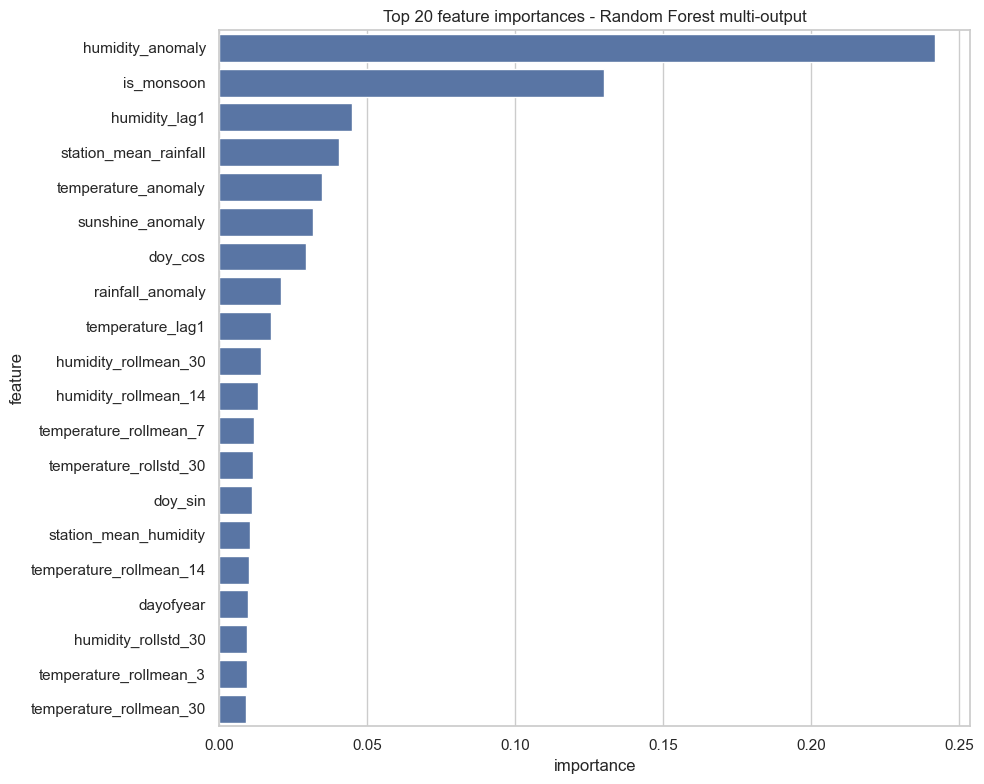

In [25]:
top20 = feature_importance.head(20)

plt.figure(figsize=(10, 8))
sns.barplot(data=top20, x="importance", y="feature")
plt.title("Top 20 feature importances - Random Forest multi-output")
plt.tight_layout()
plt.savefig("results_ml/figures/rf_feature_importance_top20.png", dpi=300)
plt.show()

## Step 20 — Prepare sequence data for station-wise Bi-LSTM





In [26]:
seq_features = ["rainfall", "temperature", "humidity", "sunshine"]

def make_station_sequences(df_station, lookback=60, horizon=1, feature_cols=seq_features):
    values = df_station[feature_cols].values
    dates = df_station["date"].values

    X, y, target_dates = [], [], []
    for i in range(len(df_station) - lookback - horizon + 1):
        X.append(values[i:i + lookback])
        y.append(values[i + lookback + horizon - 1])
        target_dates.append(dates[i + lookback + horizon - 1])

    return np.array(X), np.array(y), np.array(target_dates)

## Step 20.1 — Choose one station first


In [28]:
station_name = "dhaka"   # change later if you want
lookback = 60
horizon = 1

station_df = (
    df_daily[df_daily["station"] == station_name]
    .sort_values("date")
    .dropna(subset=seq_features)
    .copy()
)

station_df = station_df[["station", "date"] + seq_features].copy()
station_df.head()

,station,date,rainfall,temperature,humidity,sunshine
153400,dhaka,1961-01-01,0.5,21.5,80.0,0.4
153401,dhaka,1961-01-02,1.0,22.2,76.0,5.9
153402,dhaka,1961-01-03,0.0,23.1,75.0,4.2
153403,dhaka,1961-01-04,0.0,19.8,74.0,6.8
153404,dhaka,1961-01-05,0.0,16.6,68.0,10.0


## Step 20.2 — Scale only the selected station series

In [29]:
scaler = MinMaxScaler()
station_df[seq_features] = scaler.fit_transform(station_df[seq_features])

X_seq, y_seq, d_seq = make_station_sequences(
    station_df,
    lookback=lookback,
    horizon=horizon,
    feature_cols=seq_features
)

train_mask = d_seq < np.datetime64("2018-01-01")
valid_mask = (d_seq >= np.datetime64("2018-01-01")) & (d_seq < np.datetime64("2021-01-01"))
test_mask  = d_seq >= np.datetime64("2021-01-01")

X_train_seq, y_train_seq = X_seq[train_mask], y_seq[train_mask]
X_valid_seq, y_valid_seq = X_seq[valid_mask], y_seq[valid_mask]
X_test_seq, y_test_seq   = X_seq[test_mask], y_seq[test_mask]

print("X_train_seq:", X_train_seq.shape)
print("X_valid_seq:", X_valid_seq.shape)
print("X_test_seq :", X_test_seq.shape)

X_train_seq: (20759, 60, 4)
X_valid_seq: (1096, 60, 4)
X_test_seq : (1095, 60, 4)


## Step 21 — First Bi-LSTM model for one station

In [33]:
!pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable


In [34]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, LSTM, Bidirectional, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [35]:
tf.random.set_seed(42)

bilstm_model = Sequential([
     Input(shape=(lookback, len(seq_features))),
     Bidirectional(LSTM(32, return_sequences=True)),
     Dropout(0.2),
    Bidirectional(LSTM(32, return_sequences=True)),
    Dropout(0.2),
    Bidirectional(LSTM(32)),
     Dense(16, activation="swish"),
     Dense(len(seq_features))
 ])

bilstm_model.compile(
    optimizer="adam",
     loss="mae",
     metrics=["mae"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = bilstm_model.fit(
   X_train_seq, y_train_seq,
   validation_data=(X_valid_seq, y_valid_seq),
   epochs=100,
   batch_size=64,
   callbacks=[early_stop],
   verbose=1
)

Epoch 1/100
325/325 ━━━━━━━━━━━━━━━━━━━━ 26s 61ms/step - loss: 0.0864 - mae: 0.0864 - val_loss: 0.0749 - val_mae: 0.0749
Epoch 2/100
325/325 ━━━━━━━━━━━━━━━━━━━━ 19s 59ms/step - loss: 0.0716 - mae: 0.0716 - val_loss: 0.0718 - val_mae: 0.0718
Epoch 3/100
325/325 ━━━━━━━━━━━━━━━━━━━━ 21s 63ms/step - loss: 0.0685 - mae: 0.0685 - val_loss: 0.0684 - val_mae: 0.0684
Epoch 4/100
325/325 ━━━━━━━━━━━━━━━━━━━━ 23s 69ms/step - loss: 0.0668 - mae: 0.0668 - val_loss: 0.0677 - val_mae: 0.0677
Epoch 5/100
325/325 ━━━━━━━━━━━━━━━━━━━━ 24s 72ms/step - loss: 0.0658 - mae: 0.0658 - val_loss: 0.0664 - val_mae: 0.0664
Epoch 6/100
325/325 ━━━━━━━━━━━━━━━━━━━━ 24s 74ms/step - loss: 0.0649 - mae: 0.0649 - val_loss: 0.0665 - val_mae: 0.0665
Epoch 7/100
325/325 ━━━━━━━━━━━━━━━━━━━━ 24s 73ms/step - loss: 0.0647 - mae: 0.0647 - val_loss: 0.0661 - val_mae: 0.0661
Epoch 8/100
325/325 ━━━━━━━━━━━━━━━━━━━━ 23s 71ms/step - loss: 0.0642 - mae: 0.0642 - val_loss: 0.0663 - val_mae: 0.0663
Epoch 9/100
325/325 ━━━━━━━━━━━━

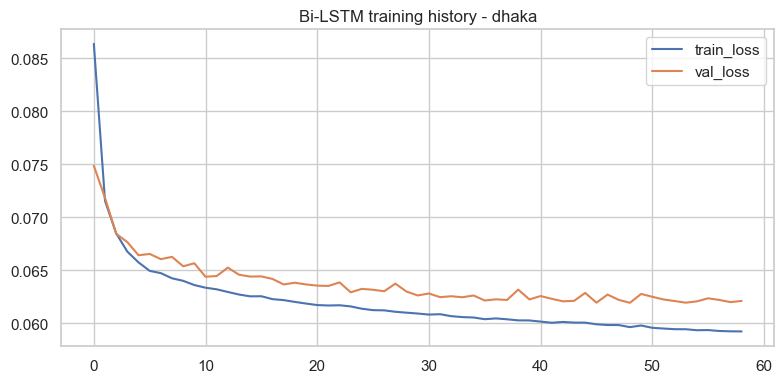

In [36]:
# Uncomment after training
plt.figure(figsize=(8, 4))
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.title(f"Bi-LSTM training history - {station_name}")
plt.legend()
plt.tight_layout()
plt.savefig(f"results_ml/figures/bilstm_history_{station_name}.png", dpi=300)
plt.show()

## Step 21.1 — Predict and evaluate the station-wise Bi-LSTM

In [37]:
# Uncomment after training
seq_pred_scaled = bilstm_model.predict(X_test_seq)

seq_pred = scaler.inverse_transform(seq_pred_scaled)
seq_true = scaler.inverse_transform(y_test_seq)

seq_pred_df = pd.DataFrame(seq_pred, columns=target_cols)
seq_true_df = pd.DataFrame(seq_true, columns=target_cols)

bilstm_results = evaluate_regression(seq_true_df, seq_pred_df, f"BiLSTM_station_{station_name}")
bilstm_results.to_csv(f"results_ml/tables/bilstm_results_{station_name}.csv", index=False)
bilstm_results

35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step


,model,target,MAE,RMSE,R2,SMAPE
0,BiLSTM_station_dhaka,target_rainfall_t1,3.997149,12.737536,0.322647,175.131298
1,BiLSTM_station_dhaka,target_temperature_t1,0.879527,1.177882,0.915519,3.349300
2,BiLSTM_station_dhaka,target_humidity_t1,4.793873,6.202815,0.695682,6.925398
3,BiLSTM_station_dhaka,target_sunshine_t1,1.830981,2.477735,0.194359,49.241331


## Step 22 — Template loop for all stations

In [38]:
def run_station_preparation(df_daily, station_name, lookback=60, horizon=1, feature_cols=seq_features):
    d = (
        df_daily[df_daily["station"] == station_name]
        .sort_values("date")
        .dropna(subset=feature_cols)
        .copy()
    )

    if len(d) < lookback + horizon + 50:
        return None

    scaler = MinMaxScaler()
    d[feature_cols] = scaler.fit_transform(d[feature_cols])

    X_seq, y_seq, d_seq = make_station_sequences(
        d,
        lookback=lookback,
        horizon=horizon,
        feature_cols=feature_cols
    )

    train_mask = d_seq < np.datetime64("2018-01-01")
    valid_mask = (d_seq >= np.datetime64("2018-01-01")) & (d_seq < np.datetime64("2021-01-01"))
    test_mask  = d_seq >= np.datetime64("2021-01-01")

    return {
        "station": station_name,
        "scaler": scaler,
        "X_train": X_seq[train_mask],
        "y_train": y_seq[train_mask],
        "X_valid": X_seq[valid_mask],
        "y_valid": y_seq[valid_mask],
        "X_test": X_seq[test_mask],
        "y_test": y_seq[test_mask]
    }

station_seq_ready = []
for st in sorted(df_daily["station"].unique()):
    out = run_station_preparation(df_daily, st, lookback=60, horizon=1)
    if out is not None and len(out["X_train"]) > 0 and len(out["X_valid"]) > 0 and len(out["X_test"]) > 0:
        station_seq_ready.append(out["station"])

print("Stations ready for sequence modeling:", len(station_seq_ready))
print(station_seq_ready)

Stations ready for sequence modeling: 35
['ambaganctg', 'barisal', 'bhola', 'bogra', 'chandpur', 'chittagong', 'chuadanga', 'comilla', 'coxsbazar', 'dhaka', 'dinajpur', 'faridpur', 'feni', 'hatiya', 'ishurdi', 'jessore', 'khepupara', 'khulna', 'kutubdia', 'madaripur', 'mcourt', 'mongla', 'mymensingh', 'patuakhali', 'rajshahi', 'rangamati', 'rangpur', 'sandwip', 'satkhira', 'sitakunda', 'srimangal', 'sydpur', 'sylhet', 'tangail', 'teknaf']


## Step 22.1 — Result table template for all station-wise deep learning runs

In [39]:
station_dl_results = pd.DataFrame(columns=["station", "target", "MAE", "RMSE", "R2", "SMAPE"])
station_dl_results

,station,target,MAE,RMSE,R2,SMAPE


## Step 23 — Final model comparison table

In [40]:
final_reg_results = all_reg_results.copy()

# If you later run xgboost, append xgb_results:
# final_reg_results = pd.concat([final_reg_results, xgb_results], ignore_index=True)

# If you later run BiLSTM for one station or all stations, append those too.

final_reg_results.to_csv("results_ml/tables/final_regression_results.csv", index=False)
final_reg_results

,model,target,MAE,RMSE,R2,SMAPE
0,Persistence_lag1,target_rainfall_t1,8.294594,22.398801,-0.567123,67.435515
1,Persistence_lag1,target_temperature_t1,1.161611,1.533516,0.866808,4.636472
2,Persistence_lag1,target_humidity_t1,4.832881,6.451286,0.438400,6.241102
3,Persistence_lag1,target_sunshine_t1,2.641139,3.621235,-0.234784,64.864788
4,RollingMean7,target_rainfall_t1,7.815058,18.393029,-0.056721,95.745302
5,RollingMean7,target_temperature_t1,1.277107,1.620987,0.851181,5.126766
6,RollingMean7,target_humidity_t1,4.786628,6.299424,0.464528,6.191103
7,RollingMean7,target_sunshine_t1,2.459872,3.156279,0.061945,56.760365
8,RandomForest_multioutput,target_rainfall_t1,5.417473,13.751254,0.409339,165.068978
9,RandomForest_multioutput,target_temperature_t1,1.014188,1.283079,0.906759,4.025165


## Step 23.1 — Best model by target

In [41]:
best_by_rmse = final_reg_results.sort_values(["target", "RMSE"]).groupby("target").head(1)
best_by_rmse.to_csv("results_ml/tables/best_model_by_target_rmse.csv", index=False)
best_by_rmse

,model,target,MAE,RMSE,R2,SMAPE
10,RandomForest_multioutput,target_humidity_t1,3.723538,4.913694,0.674200,4.818934
8,RandomForest_multioutput,target_rainfall_t1,5.417473,13.751254,0.409339,165.068978
15,ElasticNet_multioutput,target_sunshine_t1,2.072048,2.664305,0.331586,50.839428
13,ElasticNet_multioutput,target_temperature_t1,0.991252,1.280437,0.907143,3.976226
